# Notebook 10: Art Prototypes

**One Sensor, One Year — Edition 2: US Grid**

Three visual forms. One year (2025) of US-48 data. No axes, no legends. Just the data's shape, color, and rhythm.

1. **Calendar Spiral** — 365 days in a circle, stacked-fuel rings
2. **Heartbeat Strip** — horizontal timeline, stacked fuel mix; + mirrored fossil-down / clean-up variant
3. **Radial Bloom** — each day is a ray; + clean-share-gradient variant

The India edition's NB 10 used these same three forms — this port uses matching encodings with the US palette so the two editions can sit side-by-side.

**Input:** `../data/processed/us48_2025_derived.csv`

**Outputs:** PNGs in `../art/`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Wedge

PROCESSED = Path('../data/processed')
ART = Path('../art')
ART.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED / 'us48_2025_derived.csv', parse_dates=['date'], index_col='date').sort_index()
df['day_of_year'] = df.index.dayofyear

FUEL_COLS = [c for c in ['COL', 'NG', 'OIL', 'OTH', 'NUC', 'WAT', 'WND', 'SUN', 'GEO'] if c in df.columns]
for c in FUEL_COLS:
    df[c] = df[c].fillna(0)

FOSSIL = [c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in df.columns]
CLEAN  = [c for c in ['NUC', 'WAT', 'WND', 'SUN', 'GEO'] if c in df.columns]

# Ed2 fuel palette (matches build_animations.py)
PALETTE = {
    'COL': '#D4890E', 'NG':  '#F0C078', 'OIL': '#5A3825', 'OTH': '#9B72CF',
    'NUC': '#2A9D8F', 'WAT': '#264653', 'WND': '#72B352', 'SUN': '#F4C430', 'GEO': '#A0524D',
}

BG = '#FAFAF5'

if 'total_gen' not in df.columns:
    df['total_gen'] = df[FUEL_COLS].sum(axis=1)
if 'clean_share' not in df.columns:
    df['clean_share'] = df[CLEAN].sum(axis=1) / df['total_gen'] * 100

shares = df[FUEL_COLS].div(df[FUEL_COLS].sum(axis=1), axis=0)
print(f'Data ready: {len(df)} days, {len(FUEL_COLS)} fuels')

Data ready: 365 days, 9 fuels


## Form 1: Calendar Spiral

365 days in a spiral. Each day is a thin radial slice; inside that slice, fuels stack outward. The spiral shape lets a year-worth of time read as continuous motion.

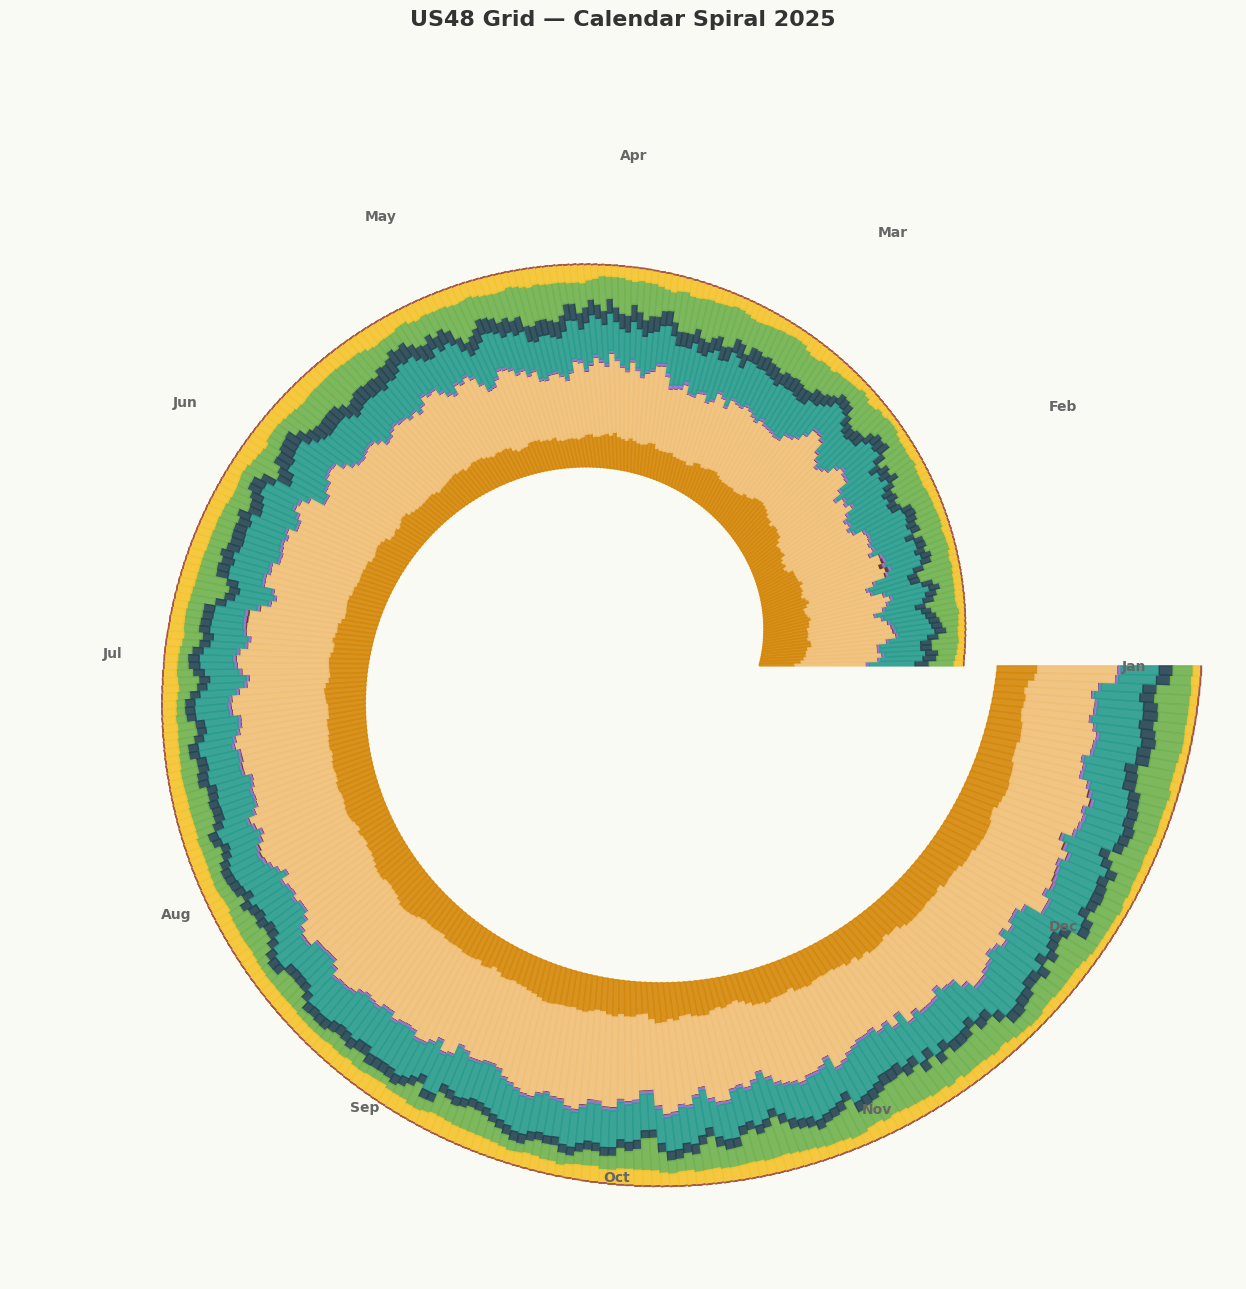

Saved ../art/proto_spiral.png


In [2]:
def draw_spiral(title=''):
    fig, ax = plt.subplots(figsize=(13, 13), facecolor=BG)
    ax.set_facecolor(BG)
    n = len(df)
    n_revs = 1.0

    for i in range(n):
        theta = (i / n) * 2 * np.pi * n_revs
        r_inner = 2.0 + (i / n) * 3.5
        total_thickness = 3.0
        d_theta = (1 / n) * 2 * np.pi * n_revs

        cum_r = r_inner
        row = shares.iloc[i]
        for fuel in FUEL_COLS:
            thick = row[fuel] * total_thickness
            if thick <= 0:
                continue
            wedge = Wedge((0, 0), cum_r + thick,
                          np.degrees(theta), np.degrees(theta + d_theta),
                          width=thick, color=PALETTE.get(fuel, '#888'), alpha=0.92)
            ax.add_patch(wedge)
            cum_r += thick

    month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    for day, label in zip(month_starts, month_labels):
        theta = (day / n) * 2 * np.pi * n_revs
        r = 7.5
        ax.text(r * np.cos(theta), r * np.sin(theta), label,
                ha='center', va='center', fontsize=10, color='#666', fontweight='bold')

    ax.set_xlim(-9, 9)
    ax.set_ylim(-9, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20, color='#333')
    plt.tight_layout()
    return fig

fig = draw_spiral('US48 Grid — Calendar Spiral 2025')
fig.savefig(ART / 'proto_spiral.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved {ART/"proto_spiral.png"}')

## Form 2: Heartbeat Strip

Stacked area across 365 days. The height at each point = total generation; colors encode fuel mix. Clean at both the daily resolution and the seasonal scale.

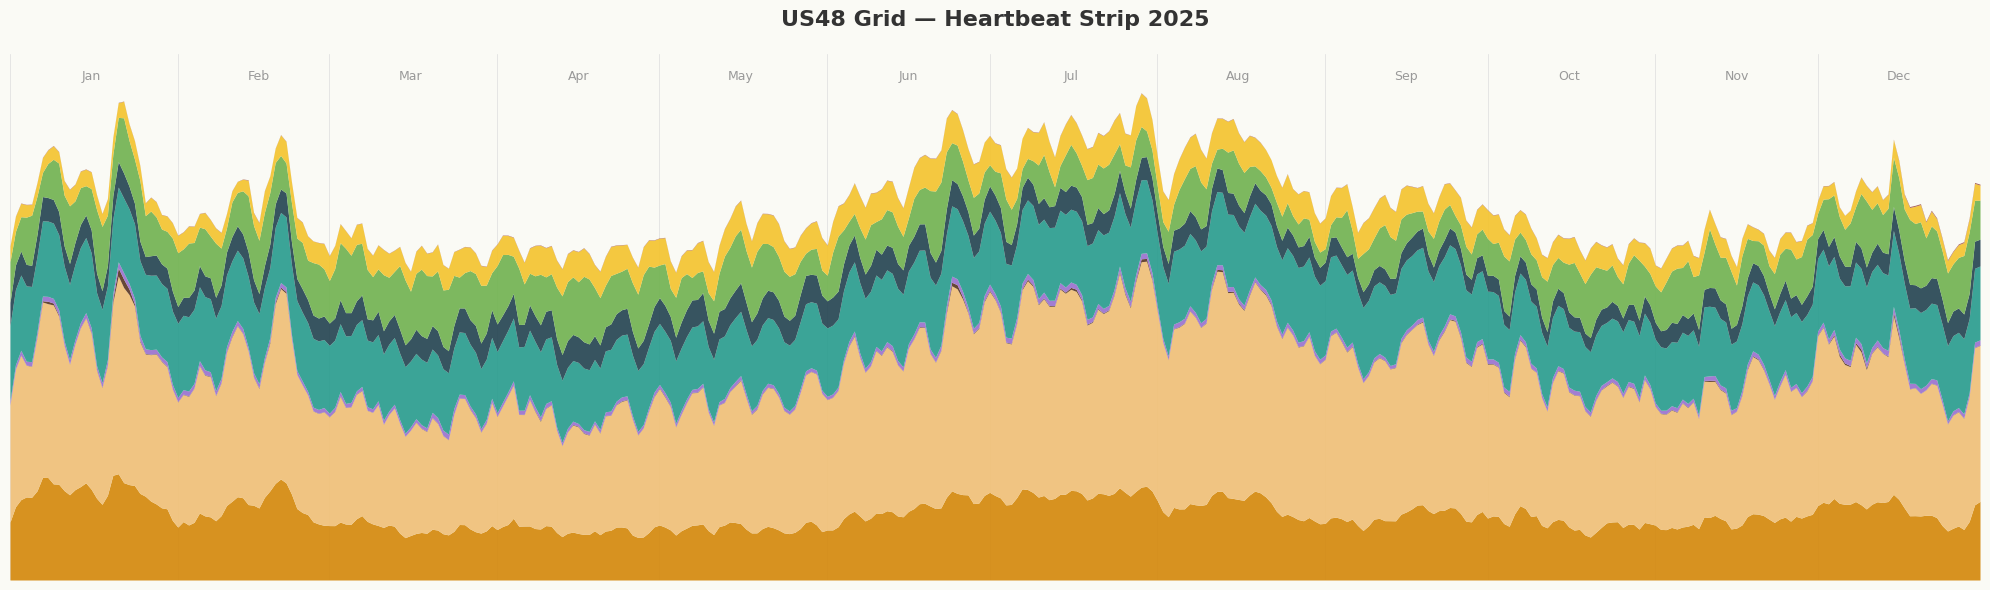

In [3]:
fig, ax = plt.subplots(figsize=(20, 6), facecolor=BG)
ax.set_facecolor(BG)
x = df['day_of_year'].values

bottom = np.zeros(len(df))
for fuel in FUEL_COLS:
    vals = df[fuel].values / 1e3  # GWh/day
    ax.fill_between(x, bottom, bottom + vals,
                    color=PALETTE.get(fuel, '#888'), alpha=0.92, linewidth=0)
    bottom += vals

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for day, label in zip(month_starts, month_labels):
    ax.axvline(day, color='#DDD', linewidth=0.5, zorder=0)
    ax.text(day + 15, bottom.max() * 1.02, label, ha='center', va='bottom',
            fontsize=9, color='#999')

ax.set_xlim(1, 365)
ax.set_ylim(0, bottom.max() * 1.08)
ax.axis('off')
ax.set_title('US48 Grid — Heartbeat Strip 2025', fontsize=16, fontweight='bold', pad=20, color='#333')
plt.tight_layout()
plt.savefig(ART / 'proto_heartbeat.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Form 2b: Mirrored Heartbeat

Fossil fuels stack downward, clean stacks upward. Zero line makes the tension visceral — the bigger the fossil mass, the harder the year leans on it.

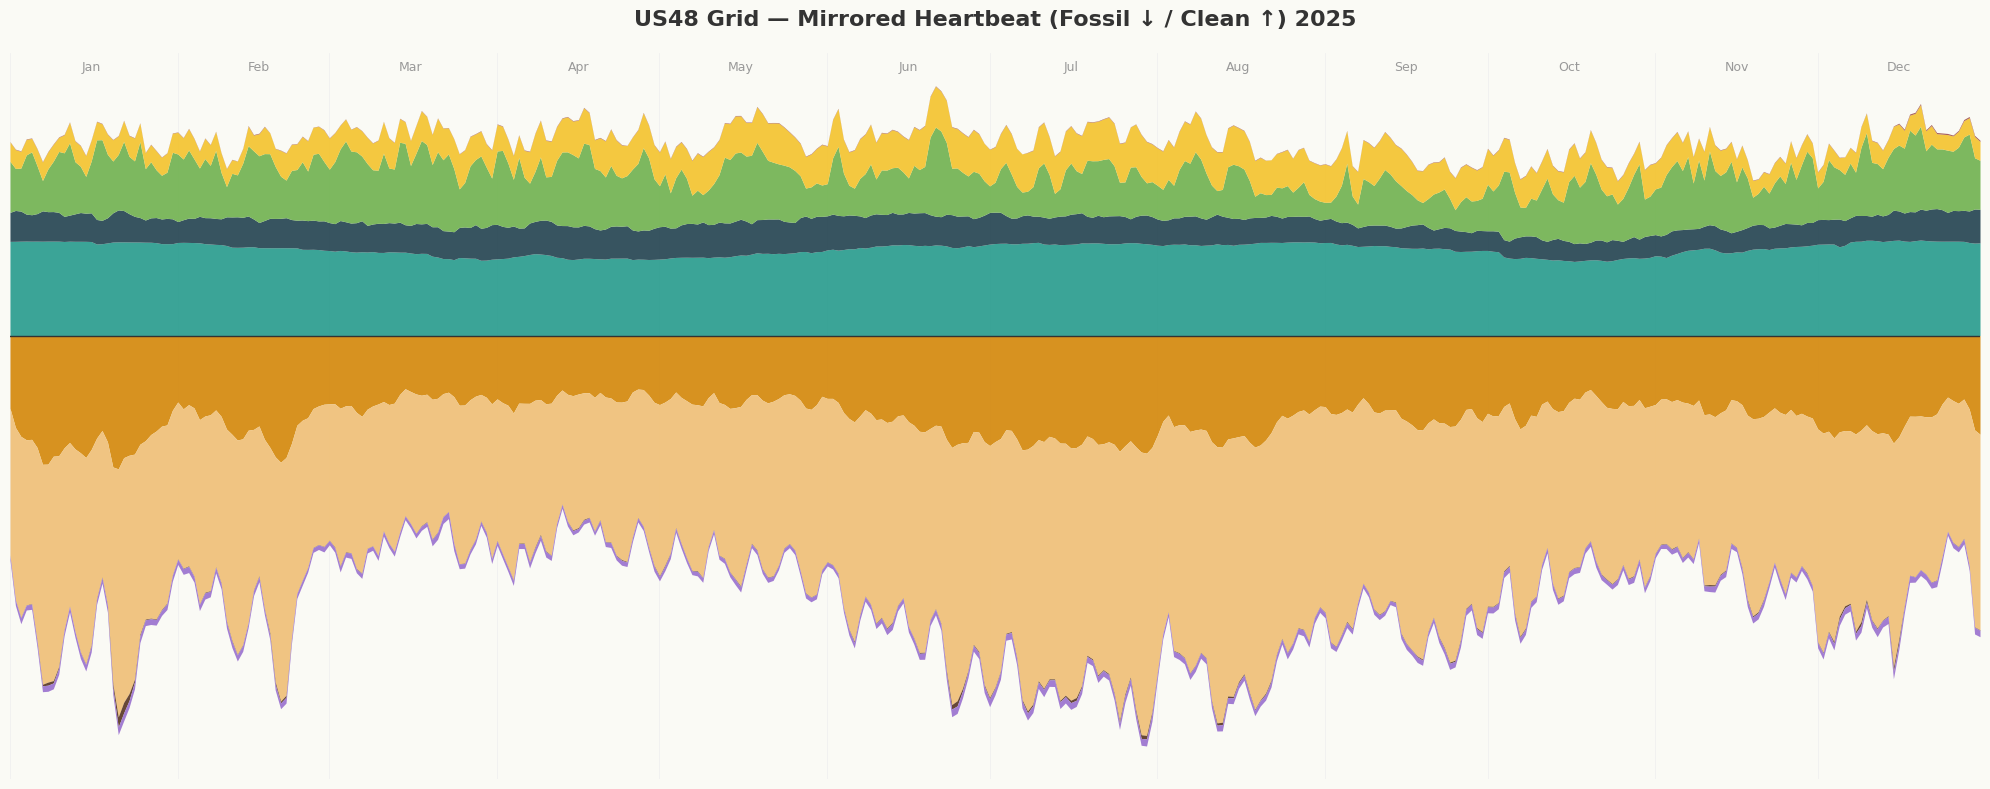

In [4]:
fig, ax = plt.subplots(figsize=(20, 8), facecolor=BG)
ax.set_facecolor(BG)
x = df['day_of_year'].values

bottom_neg = np.zeros(len(df))
for fuel in FOSSIL:
    vals = df[fuel].values / 1e3
    ax.fill_between(x, bottom_neg - vals, bottom_neg,
                    color=PALETTE.get(fuel, '#888'), alpha=0.92, linewidth=0)
    bottom_neg -= vals

bottom_pos = np.zeros(len(df))
for fuel in CLEAN:
    vals = df[fuel].values / 1e3
    ax.fill_between(x, bottom_pos, bottom_pos + vals,
                    color=PALETTE.get(fuel, '#888'), alpha=0.92, linewidth=0)
    bottom_pos += vals

ax.axhline(0, color='#333', linewidth=1)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for day, label in zip(month_starts, month_labels):
    ax.axvline(day, color='#EEE', linewidth=0.5, zorder=0)
    ax.text(day + 15, bottom_pos.max() * 1.05, label, ha='center', va='bottom',
            fontsize=9, color='#999')

ax.set_xlim(1, 365)
ax.axis('off')
ax.set_title('US48 Grid — Mirrored Heartbeat (Fossil ↓ / Clean ↑) 2025',
             fontsize=16, fontweight='bold', pad=20, color='#333')
plt.tight_layout()
plt.savefig(ART / 'proto_heartbeat_mirror.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Form 3: Radial Bloom (stacked)

Each day = one radial bar. Bar height = total daily generation. Segments = fuel share. 365 rays around a circle = a bloom.

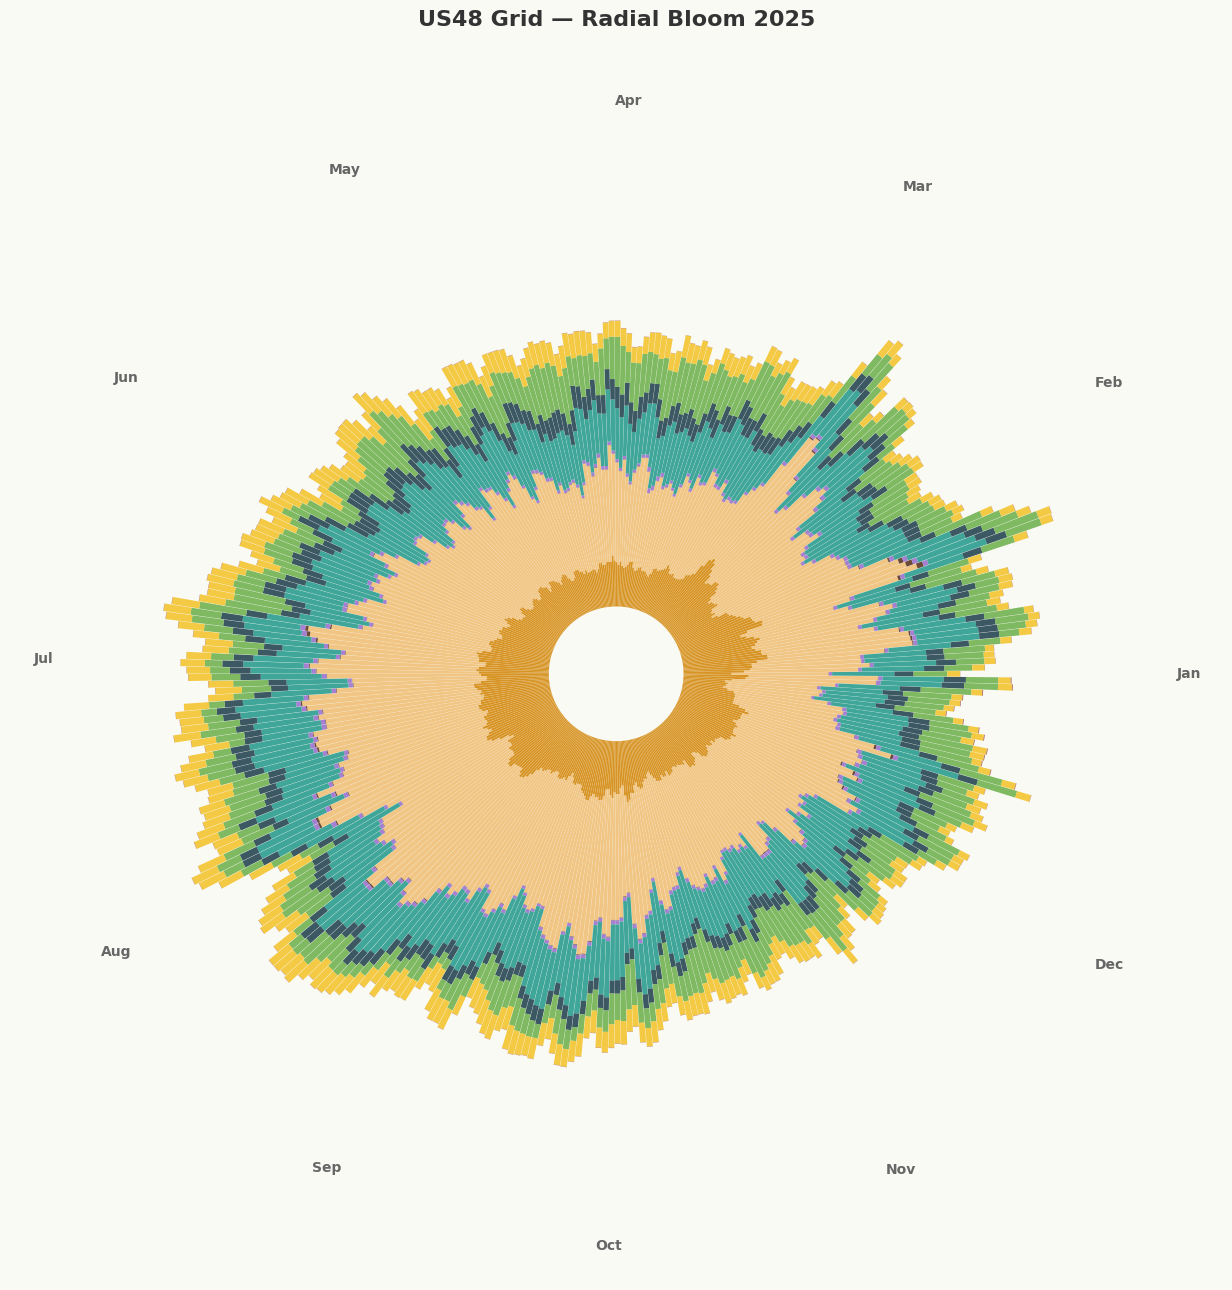

In [5]:
fig, ax = plt.subplots(figsize=(13, 13), facecolor=BG,
                        subplot_kw={'projection': 'polar'})
fig.patch.set_facecolor(BG)

n = len(df)
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
width = 2*np.pi / n * 0.95
max_total = df['total_gen'].max()

bottom = np.zeros(n)
for fuel in FUEL_COLS:
    vals = df[fuel].values / max_total * 6
    ax.bar(angles, vals, width=width, bottom=bottom + 1,
           color=PALETTE.get(fuel, '#888'), alpha=0.9, linewidth=0)
    bottom += vals

month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for day, label in zip(month_starts, month_labels):
    angle = (day / n) * 2*np.pi
    ax.text(angle, 8.5, label, ha='center', va='center',
            fontsize=10, color='#666', fontweight='bold')

ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('US48 Grid — Radial Bloom 2025', fontsize=16, fontweight='bold', pad=30, color='#333')
plt.tight_layout()
plt.savefig(ART / 'proto_bloom.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Form 3b: Radial Bloom — Clean-Share Gradient

Height encodes daily demand, color encodes how clean the grid was that day. Two variables in one bloom. The India edition's strongest art form; carried over intentionally.

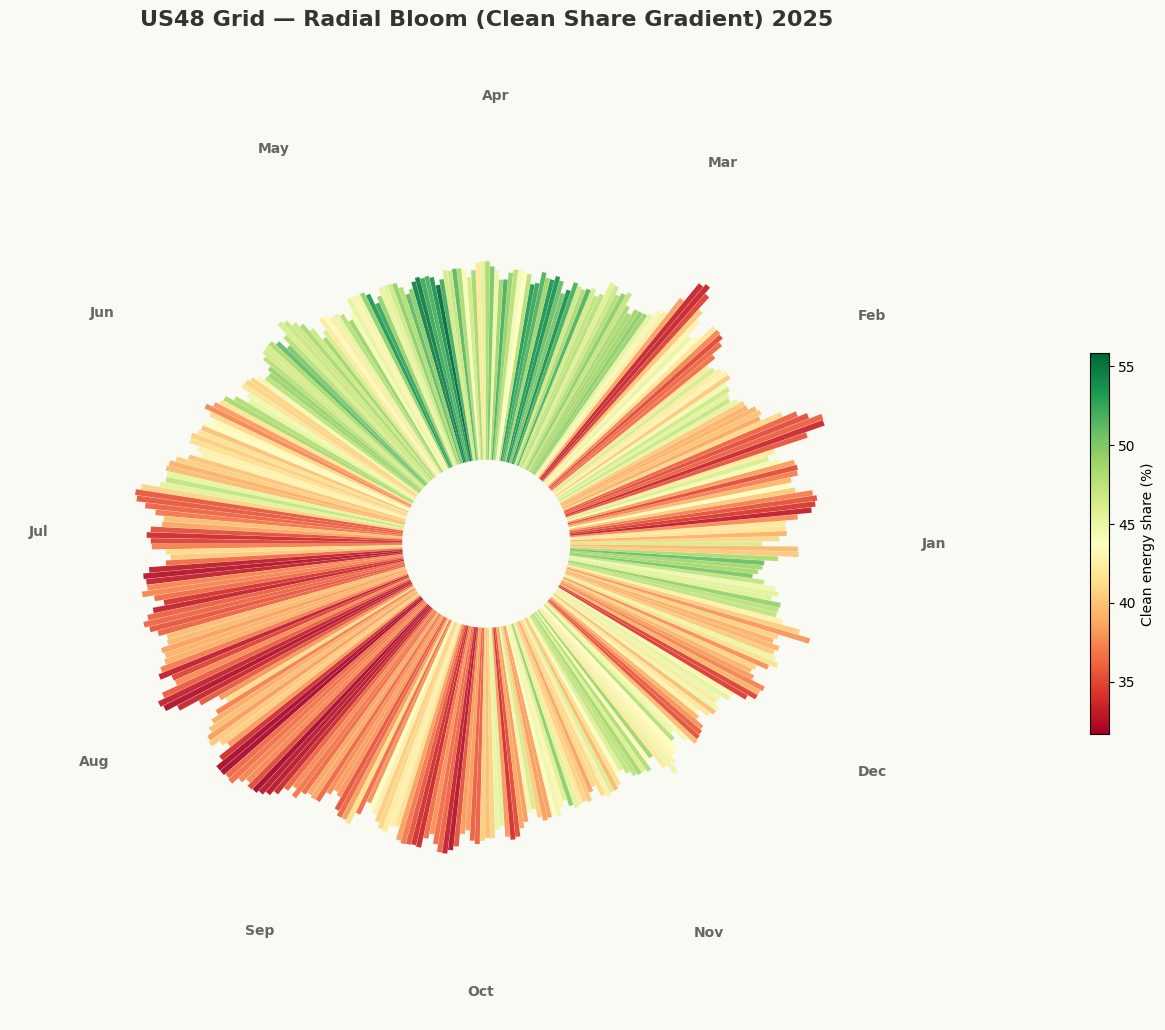

Green rays = cleanest days (spring RE surge). Red rays = dirtiest days (summer AC + gas).
The US bloom should show a spring green band and a summer red band — the opposite of India,
where monsoon summer glows green.


In [6]:
fig, ax = plt.subplots(figsize=(13, 13), facecolor=BG,
                        subplot_kw={'projection': 'polar'})
fig.patch.set_facecolor(BG)

n = len(df)
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
width = 2*np.pi / n * 0.95
max_total = df['total_gen'].max()
heights = df['total_gen'].values / max_total * 5
clean_pct = df['clean_share'].values

cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=clean_pct.min(), vmax=clean_pct.max())
colors = cmap(norm(clean_pct))

ax.bar(angles, heights, width=width, bottom=1.5,
       color=colors, alpha=0.92, linewidth=0)

month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for day, label in zip(month_starts, month_labels):
    angle = (day / n) * 2*np.pi
    ax.text(angle, 8, label, ha='center', va='center',
            fontsize=10, color='#666', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.3, pad=0.1)
cbar.set_label('Clean energy share (%)', fontsize=10)

ax.set_ylim(0, 8.5)
ax.axis('off')
ax.set_title('US48 Grid — Radial Bloom (Clean Share Gradient) 2025',
             fontsize=16, fontweight='bold', pad=30, color='#333')
plt.tight_layout()
plt.savefig(ART / 'proto_bloom_clean.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Green rays = cleanest days (spring RE surge). Red rays = dirtiest days (summer AC + gas).')
print('The US bloom should show a spring green band and a summer red band — the opposite of India,')
print('where monsoon summer glows green.')

## Key findings

1. **The heartbeat strip is the clearest read** — seasonal shifts (spring wind surge, summer gas peak, fall trough) show up visibly. Strong essay illustration.
2. **The mirrored heartbeat makes the fossil/clean ratio visceral** — US still leans heavily to the fossil side every month, with only modest spring moments where the upper half approaches the lower. A stark contrast to Ed1 India, where the monsoon months showed clean growing.
3. **The calendar spiral works for US-48 but needs more width** — we have thicker lines than India because 9 fuel codes stack vs India's 8. Legible but dense.
4. **The clean-share bloom is the poster candidate** — the spring (March–May) band should glow green, summer (Jul–Aug) should redden. One image, whole year, single clear story.
5. **Compared to India's bloom:** India's green appears in monsoon (Jul–Sep); US's green appears in spring (Mar–May). Different meteorology, same visual grammar.

→ Next: Notebook 06 — YoY Growth (needs historical data — already backfilled)